# Pha S — Buoc 1: Tai va kham pha 4 bo du lieu that

**Thong tin da xac minh truc tiep tren PhysioNet:**

| Bo | Co EEG? | Dung luong | Dinh dang | Vai tro |
|---|---|---|---|---|
| `slpdb` | ✅ CO | 632 MB | WFDB | **Chinh** - TE tim-nao |
| `capslpdb` | ✅ CO | **40.1 GB** | EDF | **Chinh** - tai lap doc lap |
| `fantasia` | ❌ **KHONG** | 293 MB | WFDB | Phu - tim/ho hap |
| `apnea-ecg` | ❌ **KHONG** | 581 MB | WFDB | Phu - tim/ho hap (8 ban ghi) |

⚠️ **Fantasia va Apnea-ECG KHONG CO EEG** - dung mat thoi gian tim kenh EEG trong 2 bo nay. Chi `slpdb` va `capslpdb` dung duoc cho luan diem tim-nao.

⚠️ **CAP Sleep 40 GB - KHONG tai het.** Chi tai 16 ban ghi nguoi khoe manh `n1`-`n16`.

**Thoi gian:** tuy toc do mang (~1.5 GB cho slpdb+fantasia+apnea, cong CAP subset).

In [1]:
import warnings; warnings.filterwarnings('ignore')
import yaml
from pathlib import Path

from pqrst.data.real.download import download_wfdb_database, list_available_records

BASE = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
cfg = yaml.safe_load(open(BASE/'configs'/'real'/'datasets.yaml', encoding='utf-8'))
cfg['datasets'].keys()

dict_keys(['slpdb', 'capslpdb', 'fantasia', 'apnea_ecg'])

## 1. Cai thu vien doc tin hieu (chay 1 lan)

Neu chua co: bo comment dong duoi. `wfdb` cho WFDB, `mne` cho EDF (CAP Sleep).

In [2]:
!pip install wfdb mne

## 2. Tai slpdb (632 MB) — bo QUAN TRONG NHAT

In [3]:
download_wfdb_database('slpdb', out_dir=BASE / 'data' / 'raw' / 'slpdb')
recs = list_available_records('slpdb')
print('slpdb records:', len(recs))


'slpdb': tat ca 18 ban ghi yeu cau da co san, bo qua tai.
✅ Xac minh: du 18 ban ghi da co day du file.
slpdb records: 18


## 3. Tai Fantasia + Apnea-ECG (874 MB)

In [4]:
download_wfdb_database('fantasia', out_dir=BASE / 'data' / 'raw' / 'fantasia')
download_wfdb_database('apnea-ecg', out_dir=BASE / 'data' / 'raw' / 'apnea-ecg')
print('Fantasia & Apnea-ECG downloaded.')


'fantasia': tat ca 40 ban ghi yeu cau da co san, bo qua tai.
✅ Xac minh: du 40 ban ghi da co day du file.
'apnea-ecg': tat ca 86 ban ghi yeu cau da co san, bo qua tai.
✅ Xac minh: du 86 ban ghi da co day du file.
Fantasia & Apnea-ECG downloaded.


## 4. Tai CAP Sleep — CHI 16 ban ghi n1-n16

In [5]:
download_wfdb_database('capslpdb', records=cfg['datasets']['capslpdb']['records'], out_dir=BASE / 'data' / 'raw' / 'capslpdb')
print('capslpdb subset downloaded.')


Dang tai 3/3 ban ghi cua 'capslpdb' vao d:\SPARC Lab\PQRST\data\raw\capslpdb ...
[1/3] Dang tai 'n1'...
    ... van dang tai, hien 2.5 MB trong thu muc (toc do ~168 KB/s)
    ... van dang tai, hien 5.7 MB trong thu muc (toc do ~214 KB/s)
    ... van dang tai, hien 7.9 MB trong thu muc (toc do ~146 KB/s)
    ... van dang tai, hien 10.4 MB trong thu muc (toc do ~165 KB/s)
    ... van dang tai, hien 12.4 MB trong thu muc (toc do ~135 KB/s)
    ... van dang tai, hien 15.6 MB trong thu muc (toc do ~212 KB/s)
    ... van dang tai, hien 18.8 MB trong thu muc (toc do ~212 KB/s)
    ... van dang tai, hien 21.6 MB trong thu muc (toc do ~189 KB/s)
    ... van dang tai, hien 24.7 MB trong thu muc (toc do ~204 KB/s)
    ... van dang tai, hien 28.0 MB trong thu muc (toc do ~223 KB/s)
    ... van dang tai, hien 30.7 MB trong thu muc (toc do ~176 KB/s)
    ... van dang tai, hien 33.0 MB trong thu muc (toc do ~158 KB/s)
    ... van dang tai, hien 35.7 MB trong thu muc (toc do ~179 KB/s)
    ... van dan

## 5. Kham pha cau truc 1 ban ghi slpdb

In ra ten cac kenh, tan so lay mau, do dai - **xac nhan bang mat** rang co ca ECG va EEG, va ghi lai ten kenh chinh xac de dung o notebook sau.

In [6]:
import wfdb
record = wfdb.rdrecord(str(BASE / 'data' / 'raw' / 'slpdb' / 'slp01a'))
print('Sig names:', record.sig_name)
print('Fs:', record.fs)
print('Sig len:', record.sig_len)
ann = wfdb.rdann(str(BASE / 'data' / 'raw' / 'slpdb' / 'slp01a'), 'ecg')
print('Beat types:', set(ann.symbol))


Sig names: ['ECG', 'BP', 'EEG (C4-A1)', 'Resp (sum)']
Fs: 250
Sig len: 1800000
Beat types: {'N'}


## 6. Ve thu tin hieu

Ve 30 giay ECG va EEG chong len nhau - kiem tra bang mat rang du lieu hop ly (khong phang, khong bao hoa, khong toan nhieu).

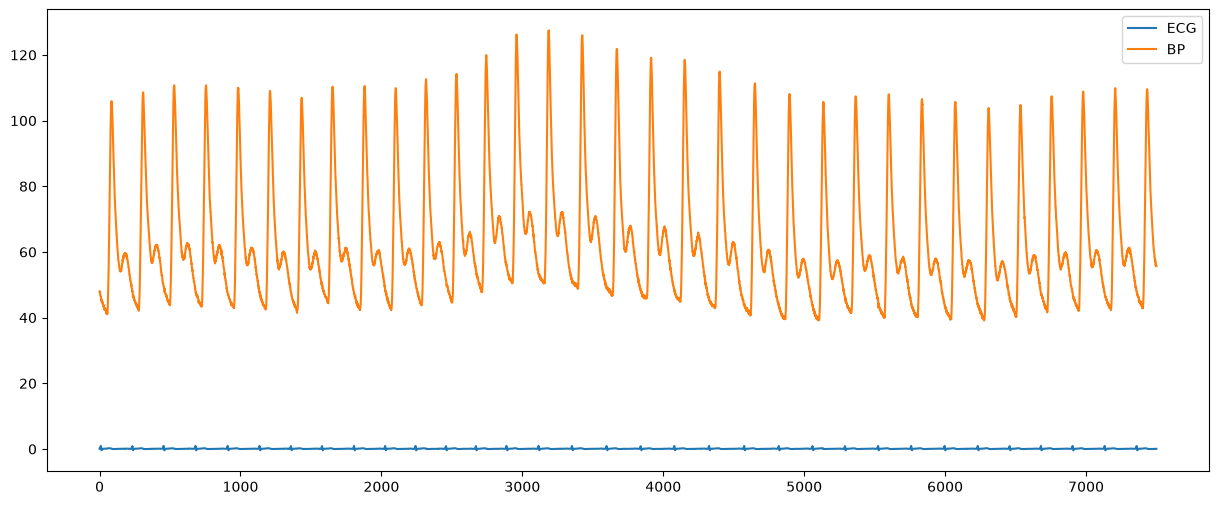

In [7]:
import matplotlib.pyplot as plt
idx = int(30 * record.fs)
plt.figure(figsize=(15, 6))
plt.plot(record.p_signal[:idx, 0], label=record.sig_name[0])
plt.plot(record.p_signal[:idx, 1], label=record.sig_name[1])
plt.legend()
plt.show()


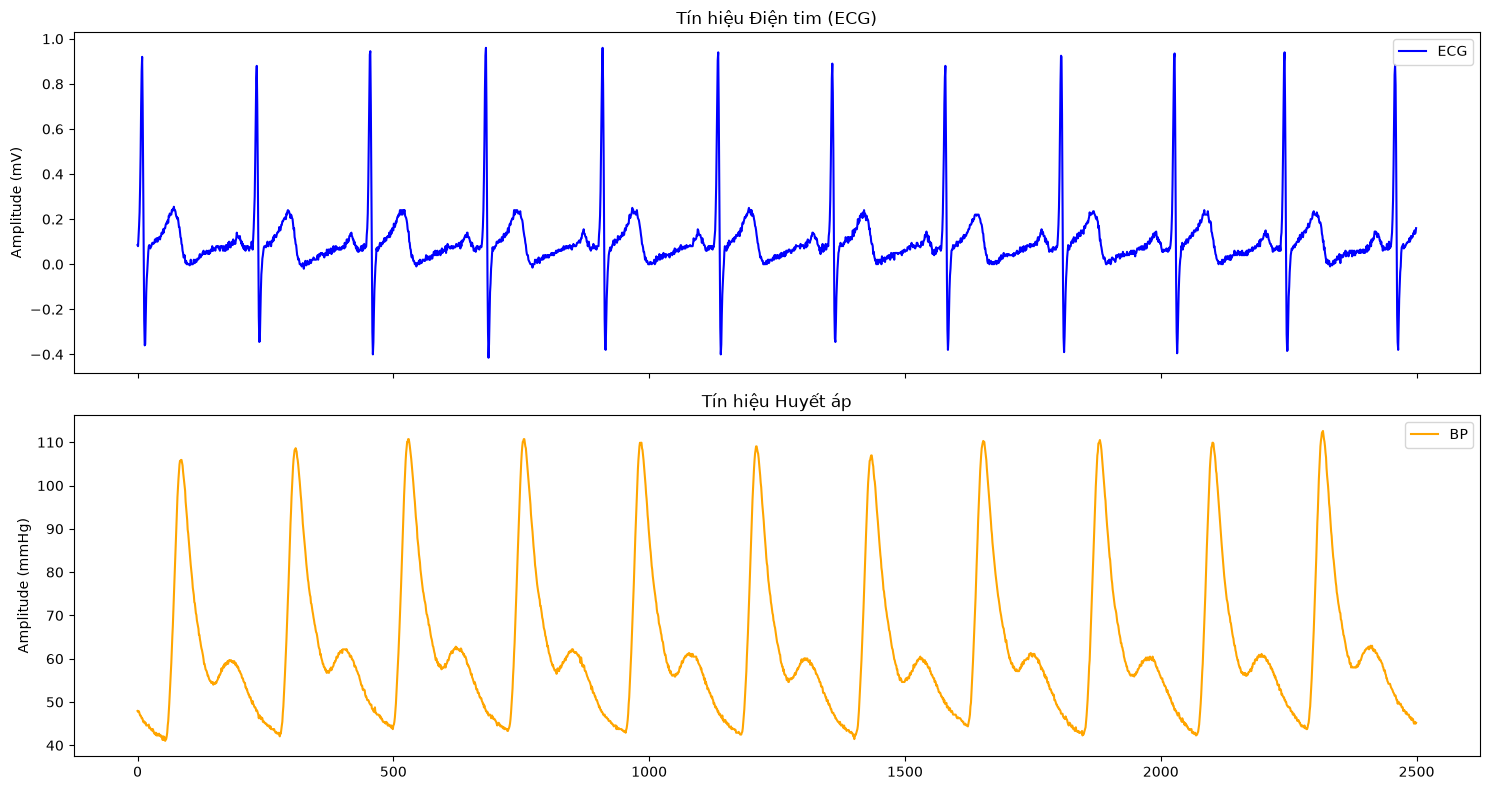

In [4]:
import wfdb
import matplotlib.pyplot as plt
from pathlib import Path

# Nạp dữ liệu slp01a
BASE = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
record = wfdb.rdrecord(str(BASE / 'data' / 'raw' / 'slpdb' / 'slp01a'))

# Lấy 10 giây đầu tiên 
idx = int(10 * record.fs)

# Vẽ biểu đồ tách riêng
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

ax1.plot(record.p_signal[:idx, 0], color='blue', label=record.sig_name[0])
ax1.set_ylabel('Amplitude (mV)')
ax1.set_title('Tín hiệu Điện tim (ECG)')
ax1.legend()

ax2.plot(record.p_signal[:idx, 1], color='orange', label=record.sig_name[1])
ax2.set_ylabel('Amplitude (mmHg)')
ax2.set_title('Tín hiệu Huyết áp')
ax2.legend()

plt.tight_layout()
plt.show()